# Load Data in

In [81]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler


In [82]:
# see more columns
pd.set_option('display.max_columns', 999)

In [83]:
df = pd.read_excel('gamezone-orders-data (1).xlsx')


In [84]:
df.shape

(21864, 11)

In [85]:
df.head()

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR


In [86]:
df.describe(include='all')

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
count,21864,21864,21864,21864,21864,21864,21859.000000,21864,21781,21781,21826
unique,19851,21719,783,NaN,9,46,NaN,2,5,5,150
top,c14ee1a5,fecc9d6766231653,2020-12-19 00:00:00,NaN,Nintendo Switch,8d0d,NaN,website,direct,desktop,US
freq,4,2,95,NaN,10386,6024,NaN,19783,17434,16458,10294
mean,NaN,NaN,NaN,2020-04-15 16:04:48.474204160,NaN,NaN,281.406583,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2018-10-18 00:00:00,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2019-11-12 00:00:00,NaN,NaN,126.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2020-05-23 00:00:00,NaN,NaN,168.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2020-10-06 00:00:00,NaN,NaN,357.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2021-11-16 00:00:00,NaN,NaN,3146.880000,NaN,NaN,NaN,NaN


# Data Cleaning 

In [87]:
#trim the spaces at the edges of every  string value in the entire dataframe
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/var/folders/sd/dlvqbkgs15xb1zf5vbzsp_2w0000gn/T/ipykernel_85141/3784830014.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [88]:
# remove duplicate order ids
df = df[~df['ORDER_ID'].duplicated(keep='first')]

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21719 entries, 0 to 21863
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   USER_ID                  21719 non-null  object        
 1   ORDER_ID                 21719 non-null  object        
 2   PURCHASE_TS              21719 non-null  object        
 3   SHIP_TS                  21719 non-null  datetime64[ns]
 4   PRODUCT_NAME             21719 non-null  object        
 5   PRODUCT_ID               21719 non-null  object        
 6   USD_PRICE                21714 non-null  float64       
 7   PURCHASE_PLATFORM        21719 non-null  object        
 8   MARKETING_CHANNEL        21636 non-null  object        
 9   ACCOUNT_CREATION_METHOD  21636 non-null  object        
 10  COUNTRY_CODE             21681 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 2.0+ MB


In [ ]:
#identify and print invalid date formats. 
failed_dates = pd.to_datetime(df['PURCHASE_TS'], errors='coerce').isna()
print(df[failed_dates & df['PURCHASE_TS'].notna()])


        USER_ID          ORDER_ID          PURCHASE_TS    SHIP_TS  \
1047   a5298a4d  0dda212aaea69940                      2019-07-08   
5846   a81bb521  4cd9ab100d971208  06-14-2019 13:62:38 2021-01-11   
11853  2fa9f33d  99d824517da22388  06-14-2019 13:62:39 2019-04-11   
16163  b313cea5  c9e0aea0d9a75871  06-14-2019 13:62:34 2019-05-18   
20725  67f8050b  f4de38506b644875  06-14-2019 13:62:41 2019-01-17   

                         PRODUCT_NAME PRODUCT_ID  USD_PRICE PURCHASE_PLATFORM  \
1047   JBL Quantum 100 Gaming Headset       ab0f      21.96           website   
5846                  Nintendo Switch       8d0d     120.26           website   
11853  JBL Quantum 100 Gaming Headset       ab0f      21.19           website   
16163  JBL Quantum 100 Gaming Headset       ab0f      19.20           website   
20725  JBL Quantum 100 Gaming Headset       ab0f      25.69           website   

      MARKETING_CHANNEL ACCOUNT_CREATION_METHOD COUNTRY_CODE  
1047             direct            

In [ ]:
# Convert PURCHASE_TS to datetime
df['PURCHASE_TS'] = pd.to_datetime(df['PURCHASE_TS'], errors='coerce')

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21719 entries, 0 to 21863
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   USER_ID                  21719 non-null  object        
 1   ORDER_ID                 21719 non-null  object        
 2   PURCHASE_TS              21714 non-null  datetime64[ns]
 3   SHIP_TS                  21719 non-null  datetime64[ns]
 4   PRODUCT_NAME             21719 non-null  object        
 5   PRODUCT_ID               21719 non-null  object        
 6   USD_PRICE                21714 non-null  float64       
 7   PURCHASE_PLATFORM        21719 non-null  object        
 8   MARKETING_CHANNEL        21636 non-null  object        
 9   ACCOUNT_CREATION_METHOD  21636 non-null  object        
 10  COUNTRY_CODE             21681 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 2.0+ MB


In [93]:
# turn blank spaces into null values
df.replace("", pd.NA, inplace=True)

In [94]:
#filter out where PURCHASE_TS is NaT
df = df[df['PURCHASE_TS'].notna()]

In [ ]:
#find where marketing channel is NA
len(df[df['MARKETING_CHANNEL'].isna()])

# We have 83 instances where marketing channel is NA, and it's usually NA along with account creation and country code, so we will remove those entries
df = df[df['MARKETING_CHANNEL'].notna()]

In [ ]:
#list out all unique country codes
df['COUNTRY_CODE'].unique()
# filter out where country code is NA=
df = df[df['COUNTRY_CODE'].notna()]

In [97]:
#filter out where USD price is NA
df = df[df['USD_PRICE'].notna()]

In [ ]:
# convert PURCHASE_TS and SHIP_TS into year month day type instead of hour type
df['PURCHASE_TS'] = df['PURCHASE_TS'].dt.to_period('D')
df['SHIP_TS'] = df['SHIP_TS'].dt.to_period('D')

In [ ]:
#identify any row where purchase_ts is greater than ship_ts
df[df['PURCHASE_TS'] > df['SHIP_TS']]

# We notice there's a considerable amount of data where there's a mismatch of purchase and shipping timestamps. As this is a fictional project, we'll pretend we flagged it, sent it over and received confirmation from our stakeholder that they were meant to be recorded the other way around. So we'll swap the values.

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE
2,9eb4efe0,0002b8350e167074,2020-04-21,2020-02-16,Nintendo Switch,8d0d,151.20,website,direct,desktop,US
3,cac7cbaf,0006d06b98385729,2020-04-07,2020-04-04,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU
4,6b0230bc,00097279a2f46150,2020-11-24,2020-08-02,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR
...,...,...,...,...,...,...,...,...,...,...,...
2002,54d69a48,1a313fc2aba37344,2019-04-05,2019-02-25,JBL Quantum 100 Gaming Headset,ab0f,21.73,website,direct,desktop,KR
2003,ffb70dda,1a32039b848108003,2020-11-17,2020-07-15,27in 4K gaming monitor,e7e6,480.00,website,direct,desktop,PE
7363,7c1b4739,60d6f8dd5dc53016,2020-12-31,2020-06-15,JBL Quantum 100 Gaming Headset,ab0f,21.46,website,direct,desktop,ES
10890,6dcd78e9,8d6795b3b1447377,2020-12-31,2020-02-20,27in 4K gaming monitor,891b,408.00,website,direct,mobile,US


In [100]:
#create a copy of PURCHASE_TS and call it PURCHASE_TS_copy
df['PURCHASE_TS_copy'] = df['PURCHASE_TS']

In [101]:
#create a copy of SHIP_TS and call it SHIP_TS_copy
df['SHIP_TS_copy'] = df['SHIP_TS']

In [102]:
# in the rows where PURCHASE_TS > SHIP_TS, set PURCHASE_TS to be equal to SHIP_TS_copy
df.loc[df['PURCHASE_TS'] > df['SHIP_TS'], 'PURCHASE_TS'] = df['SHIP_TS_copy']


In [103]:
# in the rows where PURCHASE_TS = SHIP_TS, set SHIP_TS to be equal to PURCHASE_TS_copy
df.loc[df['PURCHASE_TS_copy'] > df['SHIP_TS_copy'], 'SHIP_TS'] = df['PURCHASE_TS_copy']

In [104]:
#validate the change: identify any row where purchase_ts is greater than ship_ts
df[df['PURCHASE_TS'] > df['SHIP_TS']]

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,PURCHASE_TS_copy,SHIP_TS_copy


In [105]:
# Replace all instances of '27in 4K gaming monitor' with '27inches 4k gaming monitor'in the 'PRODUCT_NAME' column
df['PRODUCT_NAME'] = df['PRODUCT_NAME'].replace('27in 4K gaming monitor', '27inches 4k gaming monitor')
df['PRODUCT_NAME'].unique()

array(['Nintendo Switch', 'Sony PlayStation 5 Bundle',
       '27inches 4k gaming monitor', 'JBL Quantum 100 Gaming Headset',
       'Dell Gaming Mouse', 'Acer Nitro V Gaming Laptop',
       'Lenovo IdeaPad Gaming 3', 'Razer Pro Gaming Headset'],
      dtype=object)

In [106]:
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 21588 entries, 0 to 21863
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   USER_ID                  21588 non-null  object   
 1   ORDER_ID                 21588 non-null  object   
 2   PURCHASE_TS              21588 non-null  period[D]
 3   SHIP_TS                  21588 non-null  period[D]
 4   PRODUCT_NAME             21588 non-null  object   
 5   PRODUCT_ID               21588 non-null  object   
 6   USD_PRICE                21588 non-null  float64  
 7   PURCHASE_PLATFORM        21588 non-null  object   
 8   MARKETING_CHANNEL        21588 non-null  object   
 9   ACCOUNT_CREATION_METHOD  21588 non-null  object   
 10  COUNTRY_CODE             21588 non-null  object   
 11  PURCHASE_TS_copy         21588 non-null  period[D]
 12  SHIP_TS_copy             21588 non-null  period[D]
dtypes: float64(1), object(8), period[D](4)
memory usage

# Data Pre-Processing

In [ ]:
df.describe(include='all')

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,PURCHASE_TS_copy,SHIP_TS_copy
count,21588,21588,21588,21588,21588,21588,21588.000000,21588,21588,21588,21588,21588,21588
unique,19622,21588,822,777,8,46,NaN,2,5,5,150,772,826
top,07868dba,0001328c3c220830,2020-12-22,2020-12-24,Nintendo Switch,8d0d,NaN,website,direct,desktop,US,2020-12-22,2020-12-21
freq,4,1,85,90,10230,5984,NaN,19566,17304,16318,10183,93,81
mean,NaN,NaN,NaN,NaN,NaN,NaN,281.362630,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,366.047822,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,126.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,168.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,357.827500,NaN,NaN,NaN,NaN,NaN,NaN


(array([8.150e+02, 3.493e+03, 6.710e+02, 5.100e+01, 1.220e+02, 2.130e+02,
        1.301e+03, 2.661e+03, 5.802e+03, 1.200e+02, 1.100e+01, 3.800e+01,
        9.400e+01, 1.290e+02, 2.400e+02, 2.280e+02, 1.870e+02, 2.350e+02,
        2.710e+02, 5.390e+02, 4.510e+02, 3.590e+02, 1.705e+03, 8.700e+01,
        3.500e+01, 1.600e+01, 7.000e+00, 1.200e+01, 8.000e+00, 3.000e+00,
        1.000e+01, 5.000e+00, 7.000e+00, 6.000e+00, 7.000e+00, 9.000e+00,
        7.000e+00, 1.000e+01, 4.600e+01, 1.500e+01, 3.000e+00, 6.000e+00,
        1.200e+01, 1.500e+01, 1.700e+01, 2.800e+01, 1.500e+01, 1.400e+01,
        4.500e+01, 3.300e+01, 3.500e+01, 1.600e+01, 3.400e+01, 3.000e+01,
        2.200e+01, 2.300e+01, 1.800e+01, 2.850e+02, 2.400e+01, 1.100e+01,
        9.000e+00, 1.100e+01, 1.100e+01, 1.300e+01, 1.800e+01, 1.300e+01,
        1.200e+01, 1.300e+01, 2.300e+01, 9.000e+00, 7.000e+00, 1.300e+01,
        8.000e+01, 1.800e+01, 9.000e+00, 1.200e+01, 9.000e+00, 2.700e+01,
        3.200e+01, 2.800e+01, 2.800e+0

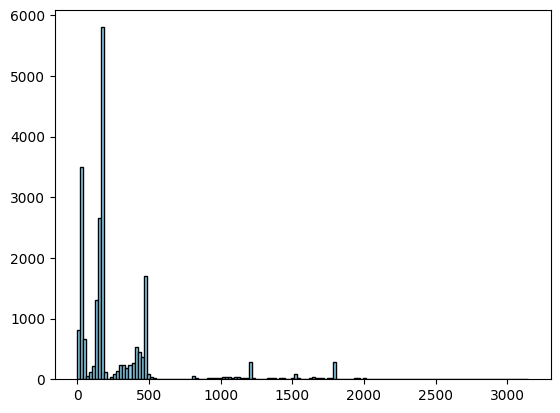

In [ ]:
#visualizing USD price
plt.hist(df['USD_PRICE'], bins=150, color='skyblue', edgecolor='black') # 'bins' defines the number of intervals


In [ ]:
# creating some features that will be used for clustering 
agg_df = df.groupby(by='USER_ID', as_index = False).agg(
    MonetaryValue =('USD_PRICE', 'sum'),
    LastPurchaseDate = ("PURCHASE_TS", 'max'),
    Frequency = ('ORDER_ID', 'nunique')
)

agg_df.describe()

,MonetaryValue,Frequency
count,19622.000000,19622.000000
mean,309.553381,1.100194
std,425.758929,0.320623
min,0.000000,1.000000
25%,126.000000,1.000000
50%,168.000000,1.000000
75%,389.905000,1.000000
max,5803.200000,4.000000


In [111]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19622 entries, 0 to 19621
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   USER_ID           19622 non-null  object   
 1   MonetaryValue     19622 non-null  float64  
 2   LastPurchaseDate  19622 non-null  period[D]
 3   Frequency         19622 non-null  int64    
dtypes: float64(1), int64(1), object(1), period[D](1)
memory usage: 613.3+ KB


In [112]:
#convert period type to datetime
agg_df['LastPurchaseDate'] = agg_df['LastPurchaseDate'].dt.to_timestamp()


In [113]:
max_purchase_date = agg_df['LastPurchaseDate'].max()

max_purchase_date

#so our last purchase date was febuary 28, 2021

Timestamp('2021-02-28 00:00:00')

In [ ]:
# add Recency column, another feature we will use for clustering
agg_df['Recency'] = (max_purchase_date - agg_df['LastPurchaseDate']).dt.days

In [115]:
agg_df.head()


,USER_ID,MonetaryValue,LastPurchaseDate,Frequency,Recency
0,185974,275.37,2020-12-10,1,80
1,249061,1041.27,2019-08-01,1,577
2,266910,168.00,2019-05-27,1,643
3,268826,392.30,2020-03-31,1,334
4,292751,168.00,2020-10-22,1,129


Text(0.5, 1.0, 'Frequency Distribution')

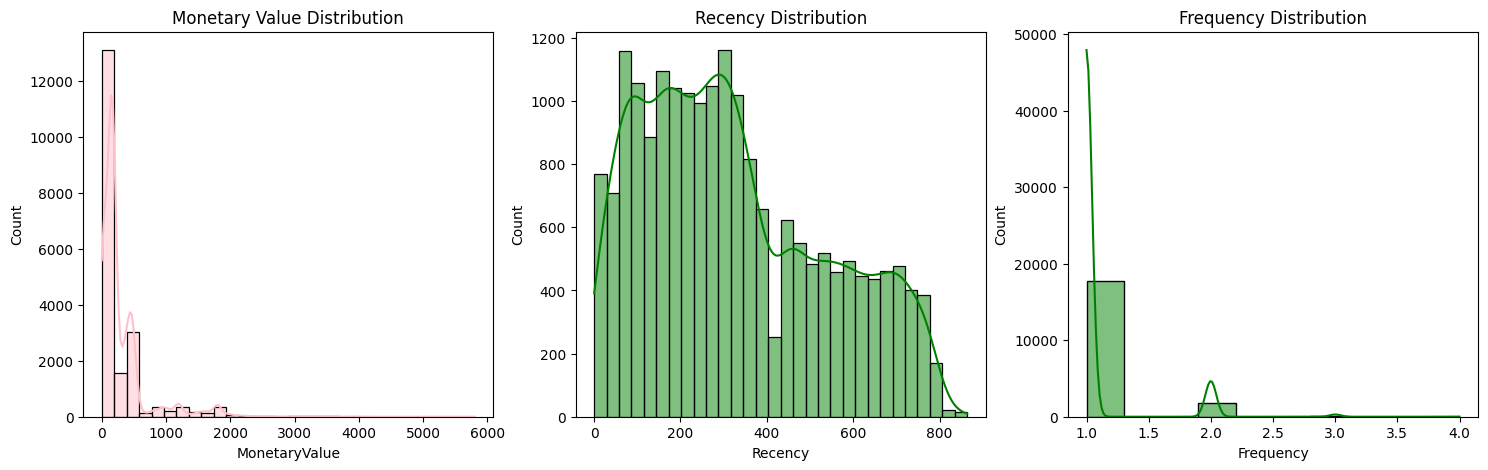

In [ ]:
# Analyze distributions of our features to check for outliers, since KMeans Clustering does not like outliers
# plot histograms of the three features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(agg_df['MonetaryValue'], bins=30, ax=axes[0], kde=True, color = "pink")
axes[0].set_title('Monetary Value Distribution')

sns.histplot(agg_df['Recency'], bins=30, ax=axes[1], kde=True, color = "green")
axes[1].set_title('Recency Distribution')

sns.histplot(agg_df['Frequency'], bins=10, ax=axes[2], kde=True, color = "green")
axes[2].set_title('Frequency Distribution')

#monetary distribution is pretty skewed. recency distribution is something. 

Text(0.5, 1.0, 'Frequency Boxplot')

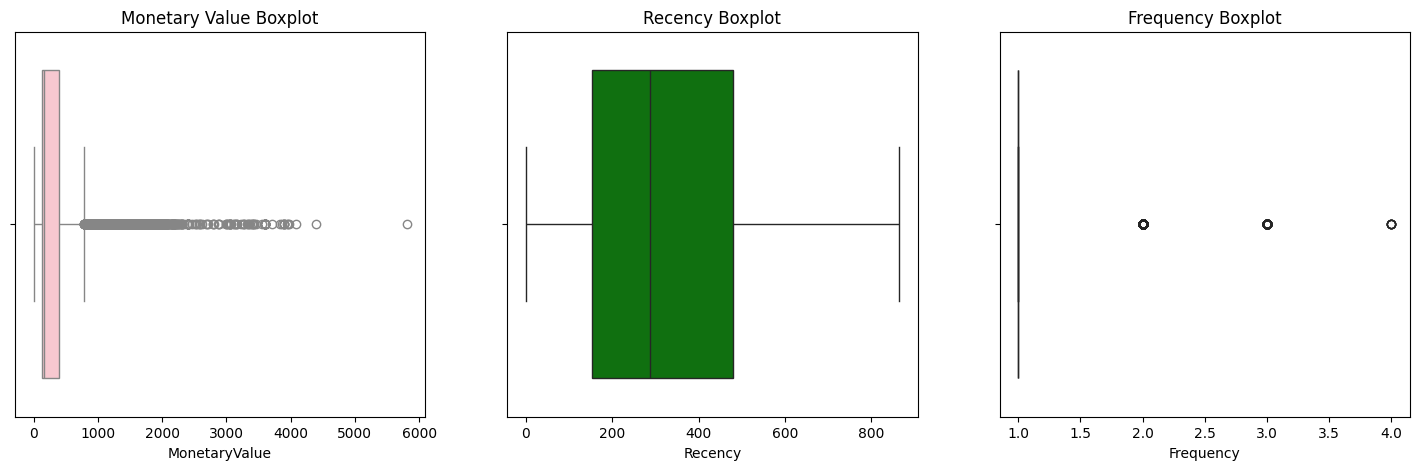

In [117]:
# using boxplot for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=agg_df['MonetaryValue'], ax=axes[0], color = "pink")
axes[0].set_title('Monetary Value Boxplot')

sns.boxplot(x=agg_df['Recency'], ax=axes[1], color = "green")
axes[1].set_title('Recency Boxplot')

sns.boxplot(x=agg_df['Frequency'], ax=axes[2], color = "green")
axes[2].set_title('Frequency Boxplot')


In [118]:
agg_df.describe(include = "all")

,USER_ID,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,19622.0,19622.000000,19622,19622.000000,19622.000000
unique,19622.0,NaN,NaN,NaN,NaN
top,185974.0,NaN,NaN,NaN,NaN
freq,1.0,NaN,NaN,NaN,NaN
mean,NaN,309.553381,2020-04-09 09:38:30.590153984,1.100194,324.598257
min,NaN,0.000000,2018-10-18 00:00:00,1.000000,0.000000
25%,NaN,126.000000,2019-11-06 00:00:00,1.000000,154.000000
50%,NaN,168.000000,2020-05-16 00:00:00,1.000000,288.000000
75%,NaN,389.905000,2020-09-27 00:00:00,1.000000,480.000000
max,NaN,5803.200000,2021-02-28 00:00:00,4.000000,864.000000


In [ ]:
# Separating the outliers
# We can get quartiles in agg_df.describe(), but we'll write out the formulas to be more rigorous


Q1_monetary = agg_df['MonetaryValue'].quantile(0.25)
Q3_monetary = agg_df['MonetaryValue'].quantile(0.75)
IQR_monetary = Q3_monetary - Q1_monetary

# filter out recency too
Q1_recency = agg_df['Recency'].quantile(0.25)
Q3_recency = agg_df['Recency'].quantile(0.75)
IQR_recency = Q3_recency - Q1_recency

# and frequency outliers
Q1_frequency = agg_df['Frequency'].quantile(0.25)
Q3_frequency = agg_df['Frequency'].quantile(0.75)
IQR_frequency = Q3_frequency - Q1_frequency



In [120]:
# create a table of main data values, then outlier values

monetary_outliers_df = agg_df[(agg_df['MonetaryValue'] < (Q1_monetary - 1.5 * IQR_monetary)) | (agg_df['MonetaryValue'] > (Q3_monetary + 1.5 * IQR_monetary))]

recency_outliers_df = agg_df[(agg_df['Recency'] < (Q1_recency - 1.5 * IQR_recency)) | (agg_df['Recency'] > (Q3_recency + 1.5 * IQR_recency))]

frequency_outliers_df = agg_df[(agg_df['Frequency'] < (Q1_frequency - 1.5 * IQR_frequency)) | (agg_df['Frequency'] > (Q3_frequency + 1.5 * IQR_frequency))]

In [121]:
monetary_outliers_df.describe()

,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,1750.000000,1750,1750.000000,1750.000000
mean,1467.930086,2020-06-03 20:13:42.857143040,1.293143,269.157143
min,786.940000,2018-11-05 00:00:00,1.000000,0.000000
25%,1055.305000,2020-02-23 06:00:00,1.000000,111.000000
50%,1292.200000,2020-07-19 00:00:00,1.000000,224.000000
75%,1800.000000,2020-11-09 00:00:00,2.000000,370.750000
max,5803.200000,2021-02-28 00:00:00,4.000000,846.000000
std,565.803382,NaN,0.524210,192.980104


In [122]:
recency_outliers_df.describe()

,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,0.0,0,0.0,0.0
mean,NaN,NaT,NaN,NaN
min,NaN,NaT,NaN,NaN
25%,NaN,NaT,NaN,NaN
50%,NaN,NaT,NaN,NaN
75%,NaN,NaT,NaN,NaN
max,NaN,NaT,NaN,NaN
std,NaN,NaN,NaN,NaN


In [123]:
frequency_outliers_df.describe()

,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,1847.000000,1847,1847.000000,1847.000000
mean,633.756248,2020-06-17 17:22:22.934488064,2.064429,255.276123
min,0.000000,2019-01-01 00:00:00,2.000000,0.000000
25%,299.800000,2019-12-19 00:00:00,2.000000,76.000000
50%,336.000000,2020-09-01 00:00:00,2.000000,180.000000
75%,777.130000,2020-12-14 00:00:00,2.000000,437.000000
max,5803.200000,2021-02-28 00:00:00,4.000000,789.000000
std,738.689129,NaN,0.256374,204.818673


In [124]:
# making non outliers data frame
non_outliers_df = agg_df[(~agg_df.index.isin(monetary_outliers_df.index)) & (~agg_df.index.isin(recency_outliers_df.index)) & (~agg_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,16484.000000,16484,16484.0,16484.000000
mean,186.180008,2020-03-29 17:31:57.495753216,1.0,335.269473
min,0.000000,2018-10-18 00:00:00,1.0,0.000000
25%,57.520000,2019-10-21 00:00:00,1.0,164.000000
50%,168.000000,2020-05-06 00:00:00,1.0,298.000000
75%,176.130000,2020-09-17 00:00:00,1.0,496.000000
max,783.280000,2021-02-28 00:00:00,1.0,864.000000
std,146.393549,NaN,0.0,213.055923


In [125]:
agg_df.describe()

,MonetaryValue,LastPurchaseDate,Frequency,Recency
count,19622.000000,19622,19622.000000,19622.000000
mean,309.553381,2020-04-09 09:38:30.590153984,1.100194,324.598257
min,0.000000,2018-10-18 00:00:00,1.000000,0.000000
25%,126.000000,2019-11-06 00:00:00,1.000000,154.000000
50%,168.000000,2020-05-16 00:00:00,1.000000,288.000000
75%,389.905000,2020-09-27 00:00:00,1.000000,480.000000
max,5803.200000,2021-02-28 00:00:00,4.000000,864.000000
std,425.758929,NaN,0.320623,212.497204


Text(0.5, 1.0, 'Recency Boxplot')

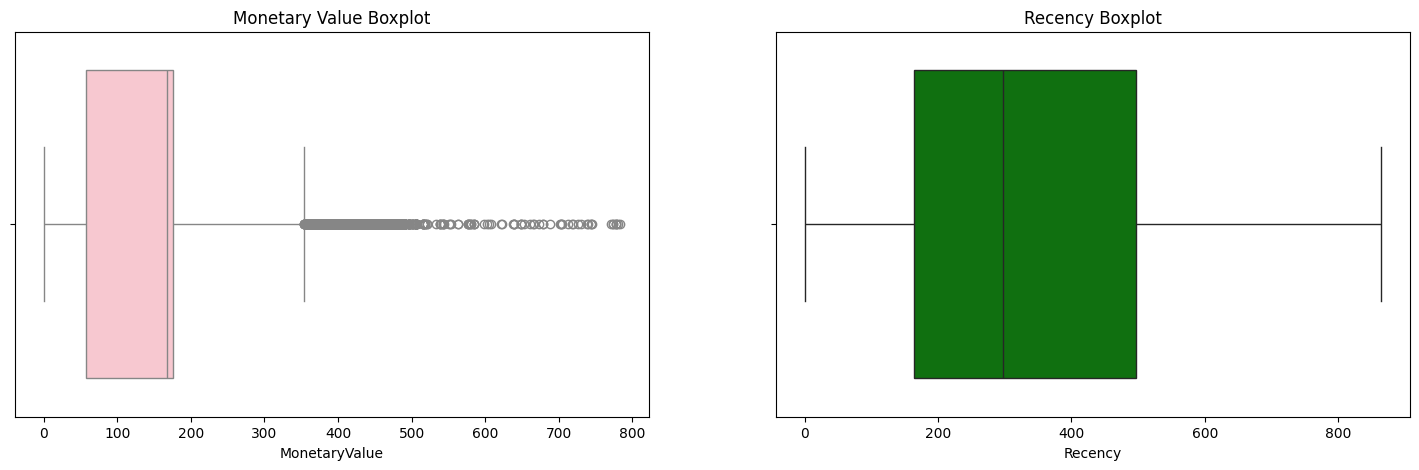

In [ ]:
# recreate boxplots for non outliers dataframe

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(x=non_outliers_df['MonetaryValue'], ax=axes[0], color = "pink")
axes[0].set_title('Monetary Value Boxplot')

sns.boxplot(x=non_outliers_df['Recency'], ax=axes[1], color = "green")
axes[1].set_title('Recency Boxplot')


# There are still outliers for monetary, but that's to be expected. 

<Axes: xlabel='Recency', ylabel='MonetaryValue'>

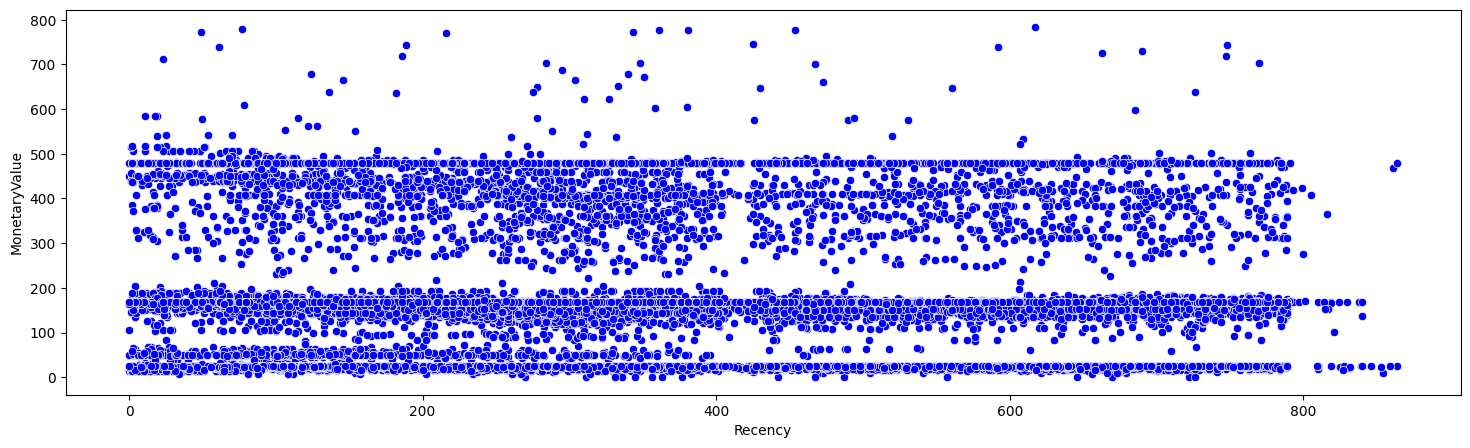

In [127]:
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
# create scatterplot of monetary vs recency
sns.scatterplot(data=non_outliers_df, x='Recency', y='MonetaryValue', ax=axes, color='blue')


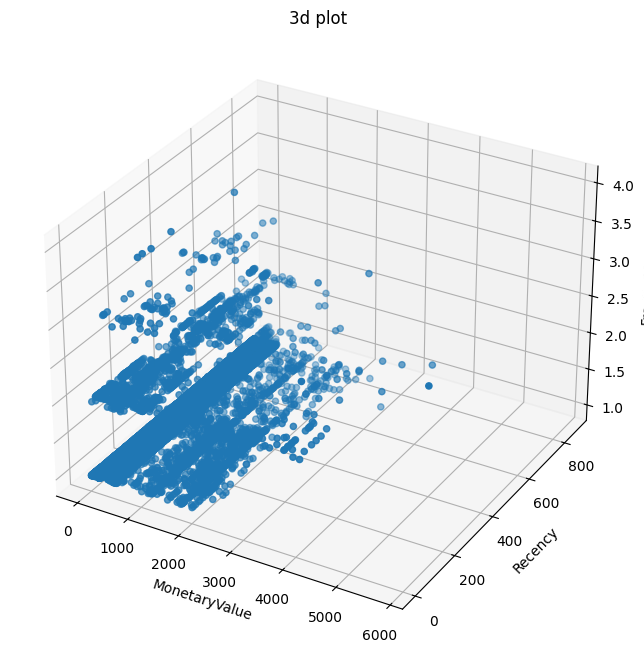

In [ ]:
# 3D Plot of graph with outlier and nonoutlier inclusive
fig = plt.figure(figsize= (8,8))

ax = fig.add_subplot(projection = "3d")

scatter = ax.scatter(agg_df['MonetaryValue'], agg_df['Recency'], agg_df['Frequency'])

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Recency')
ax.set_zlabel('Frequency')

ax.set_title('3d plot')

plt.show()



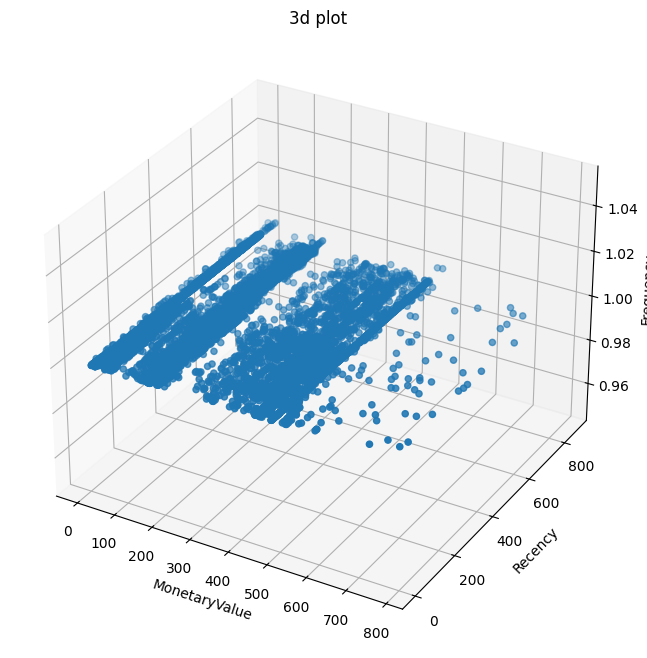

In [ ]:
# 3D Plot of graph with just non outliers. Frequency only has one value, so 3d visualization isn't needed. 

ig = plt.figure(figsize= (8,8))

ax = fig.add_subplot(projection = "3d")

scatter = ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Recency'], non_outliers_df['Frequency'])

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Recency')
ax.set_zlabel('Frequency')

ax.set_title('3d plot')

plt.show()



In [ ]:
# apply standardized scaling for monetary value and recency

scaler = StandardScaler()

# transforming monetary value and recency and storing into scaled data array 
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'Recency', 'Frequency']])

# converting array back to dataframe
scaled_df = pd.DataFrame(scaled_data,index = non_outliers_df.index, columns=['MonetaryValue', 'Recency', 'Frequency'])

scaled_df

,MonetaryValue,Recency,Frequency
0,0.609267,-1.198170,0.0
2,-0.124190,1.444409,0.0
3,1.408028,-0.005959,0.0
4,-0.124190,-0.968176,0.0
6,-0.124190,-0.996339,0.0
...,...,...,...
19615,-1.104522,-0.451864,0.0
19618,-0.124190,-1.198170,0.0
19619,-0.124190,-0.142077,0.0
19620,2.007116,-1.564282,0.0


# K Means Clustering

### Finding k using inertia and silhouette score

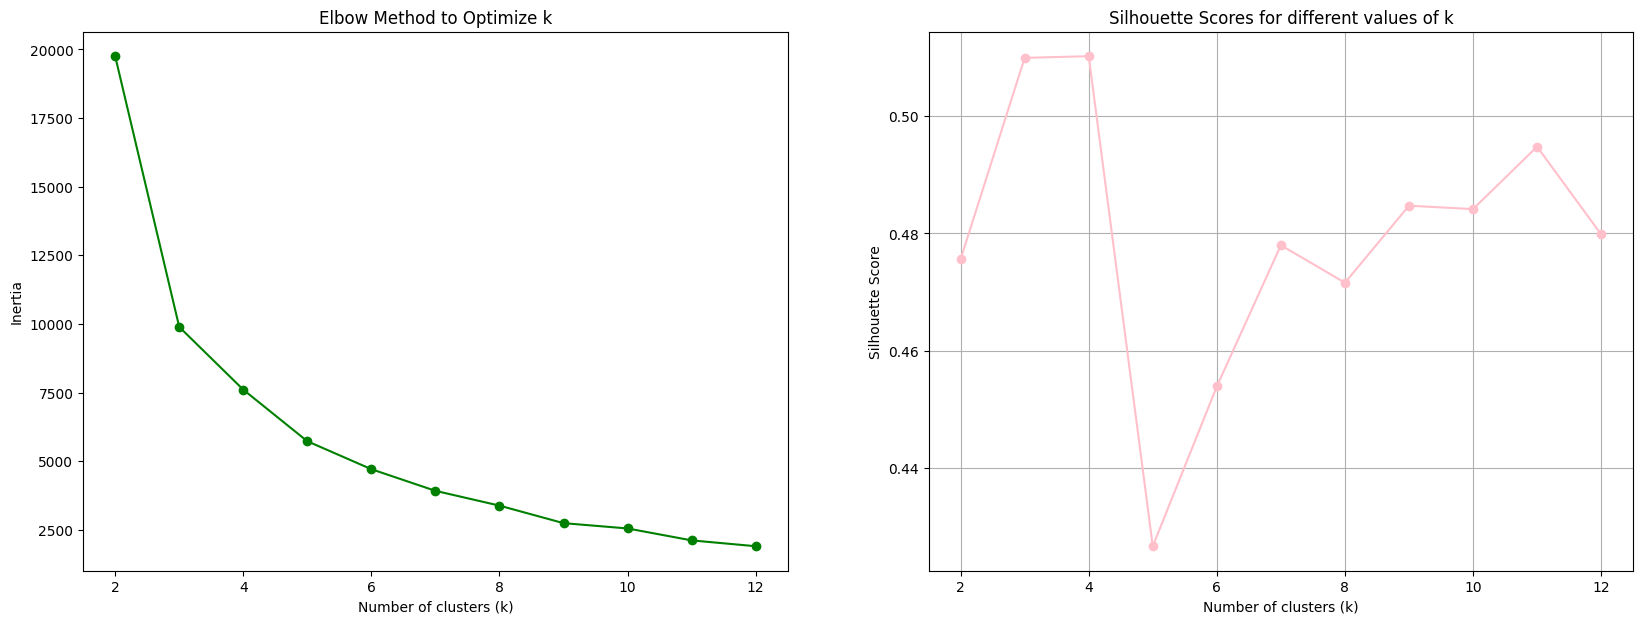

In [131]:
max_k = 12

inertia = []
silhouette_scores = []

k_values = range(2, max_k + 1)

for k in k_values :
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter = 1000)
    cluster_labels = kmeans.fit_predict(scaled_df)
    sil_score = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)


plt.figure(figsize = (20, 7))

plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker='o', color = 'green')
plt.title('Elbow Method to Optimize k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(k_values, silhouette_scores, marker='o', color = 'pink')
plt.title('Silhouette Scores for different values of k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.grid()
plt.show()

### Finalizing Our Model

In [ ]:
# Let's choose k = 4

kmeans = KMeans(n_clusters= 4, random_state=42, max_iter = 1000)

cluster_labels = kmeans.fit_predict(scaled_df)

cluster_labels

array([0, 3, 2, ..., 0, 2, 3], shape=(16484,), dtype=int32)

In [133]:
# calculating WCSS aka inertia for our model
kmeans.inertia_
wcss_value = kmeans.inertia_

In [134]:
# calculating WCSS aka intertia for k means baseline = 1
kmeans_baseline = KMeans(n_clusters= 1, random_state=42, max_iter = 1000)
kmeans_baseline.fit_predict(scaled_df)
wcss_value_baseline = kmeans_baseline.inertia_

In [135]:
# calculating percent of reduction

(wcss_value_baseline - wcss_value) / wcss_value_baseline 

# so we have percent reduction of 77%

0.7692570174714722

In [136]:
#create a column called "Cluster" in our non-outliers DataFrame, which contains the row's assigned cluster number 
non_outliers_df['Cluster'] = cluster_labels

non_outliers_df.head(10)

/var/folders/sd/dlvqbkgs15xb1zf5vbzsp_2w0000gn/T/ipykernel_85141/3061999875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster'] = cluster_labels


,USER_ID,MonetaryValue,LastPurchaseDate,Frequency,Recency,Cluster
0,185974,275.37,2020-12-10,1,80,0
2,266910,168.00,2019-05-27,1,643,3
3,268826,392.30,2020-03-31,1,334,2
4,292751,168.00,2020-10-22,1,129,0
6,312959,168.00,2020-10-28,1,123,0
7,332998,167.35,2019-07-27,1,582,3
8,387435,21.60,2020-04-06,1,328,0
10,631691,177.11,2020-07-20,1,223,0
11,758931,168.00,2021-01-28,1,31,0
12,970353,84.49,2020-06-17,1,256,0


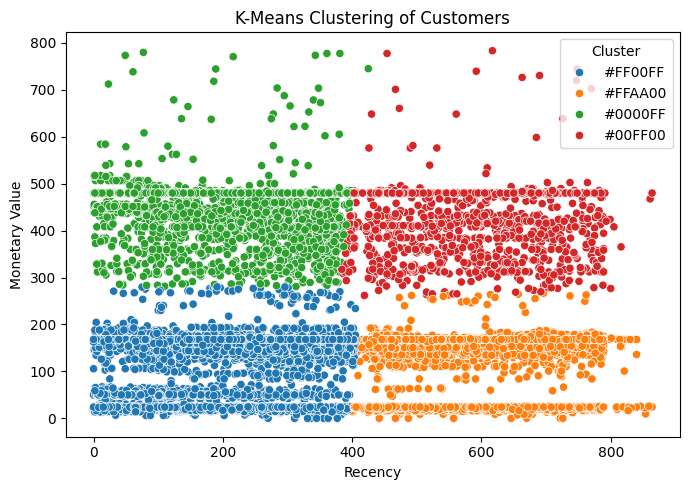

In [138]:
# mapping our clusters to colors for visualization
cluster_colors = {0: '#FF00FF', 
                  1: '#00FF00', 
                  2: '#0000FF',
                  3: "#FFAA00"}





color = non_outliers_df['Cluster'].map(cluster_colors)

# plotting the clusters
fig = plt.subplots(1, 1, figsize=(7, 5))
sns.scatterplot(data=non_outliers_df, 
                x='Recency', 
                y='MonetaryValue', 
                hue=color # using the mapped colors
)

# labels
plt.title('K-Means Clustering of Customers')
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.tight_layout()

plt.show()


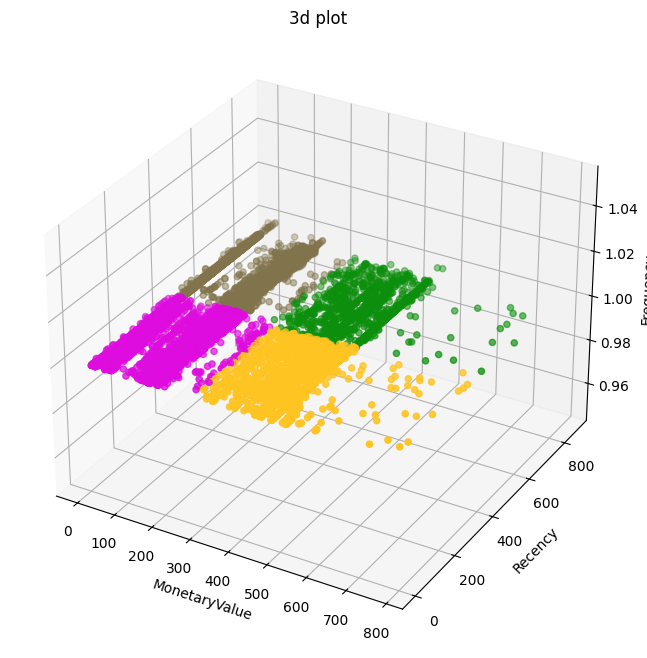

In [139]:
# mapping our clusters to colors for visualization
cluster_colors = {0: "#DE0CDE", 
                  1: "#0C8F0C", 
                  2: "#FFC421",
                  3: "#81744C"
                  }

colors = non_outliers_df['Cluster'].map(cluster_colors)


fig = plt.figure(figsize= (8,8))

ax = fig.add_subplot(projection = "3d")

scatter = ax.scatter(non_outliers_df['MonetaryValue'],
                     non_outliers_df['Recency'], 
                     non_outliers_df['Frequency'],
                     c = colors, #map colors
                     marker = 'o'
                     )

ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Recency')
ax.set_zlabel('Frequency')

ax.set_title('3d plot')

plt.show()



# Non-Outliers Data Frame Analysis

Text(0, 0.5, 'Recency')

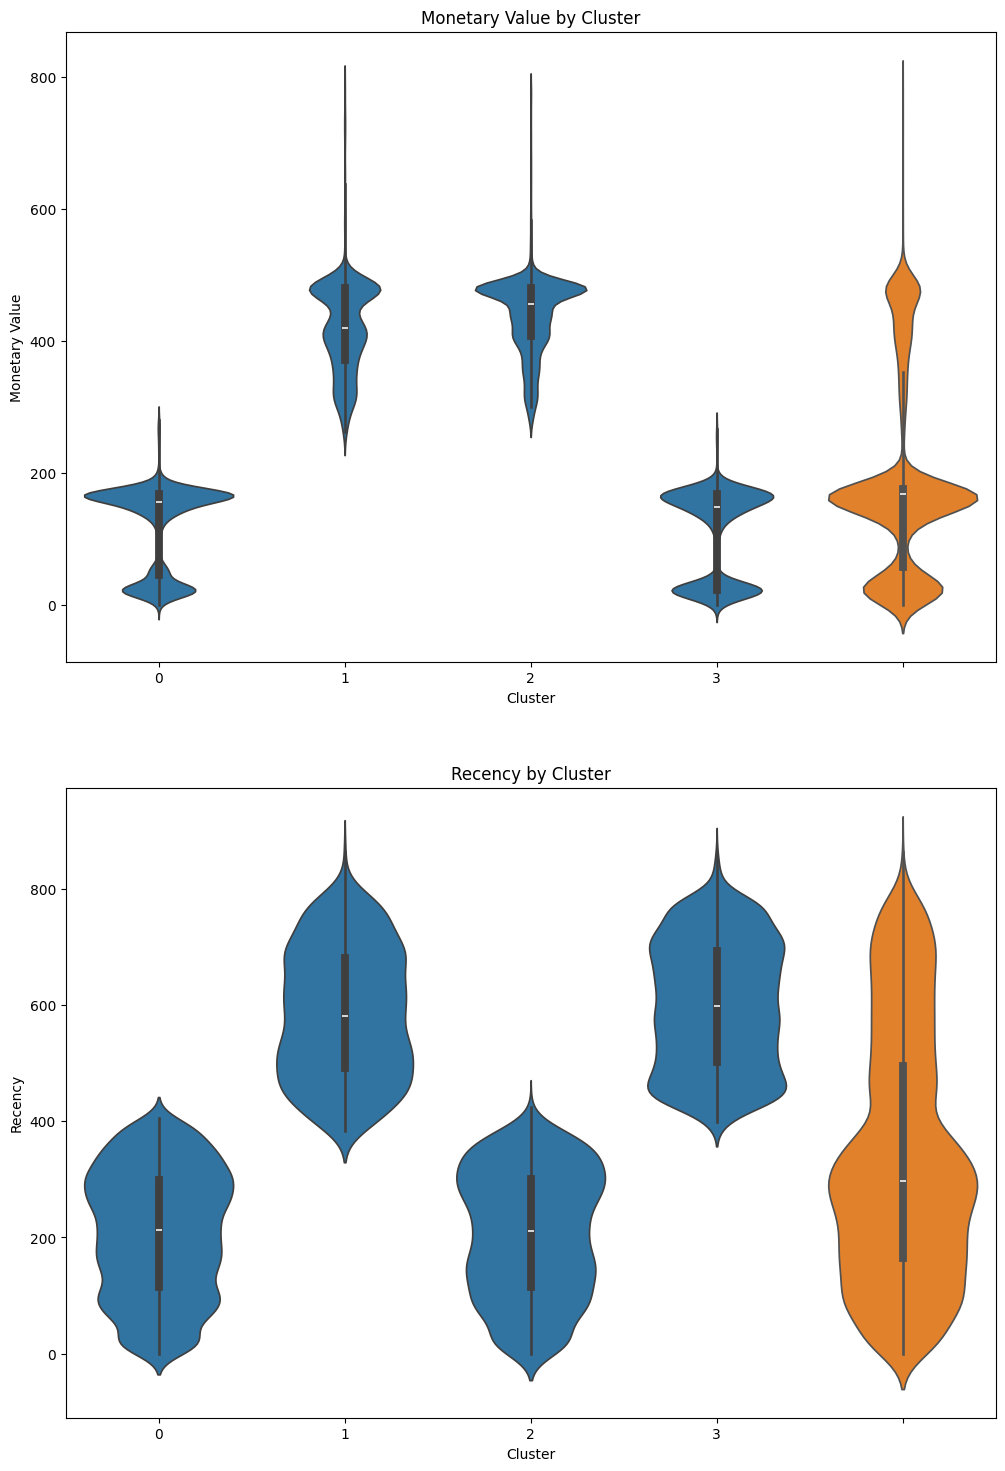

In [140]:
plt.figure(figsize= (12,18))

plt.subplot(2, 1, 1)
sns.violinplot(x = non_outliers_df['Cluster'], y = non_outliers_df['MonetaryValue'])
sns.violinplot(y = non_outliers_df['MonetaryValue'])
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(2, 1, 2)
sns.violinplot(x = non_outliers_df['Cluster'], y = non_outliers_df['Recency'])
sns.violinplot(y = non_outliers_df['Recency'])
plt.title('Recency by Cluster')
plt.ylabel('Recency')



In [141]:
#checking how many customers we have in each cluster
non_outliers_df['Cluster'].value_counts()

Cluster
0    8602
3    4276
2    2447
1    1159
Name: count, dtype: int64

# Intervention Strategy Simulation

In [158]:
# due to limited data, treatment effects are assumed
# "Industry averages suggest a 5–10% lift for personalized re-engagement"


# Conservative: Use 2–5% for loyal groups.

# Moderate: Use 5–10% for general users.

# Aggressive: Use 10–20% for "win-back" campaigns for churning users.


In [159]:
# 1. we have 4 clusters from our K-Means
# Cluster 1: At-Risk, Cluster 0: Average, Cluster 2: VIPs

# 2. Define Baseline Retention (If we did nothing)
cluster_base_rates = {0: 0.69732978, 1: 0.12040556, 2: 0.7, 3: 0.1}
joined_non_outliers_df['base_retention'] = joined_non_outliers_df['Cluster'].map(cluster_base_rates)

# 3. Simulate the "Treatment Effect" (The impact of your cluster-specific strategy)
# Strategy: High-intensity intervention for Cluster 1 gives a +10% boost
# Strategy: Personalized engagement for Cluster 0 gives a +5% boost
lift_effects = {0: 0.05, 1: 0.10, 2: 0.02, 3:.04}
joined_non_outliers_df['lift_effect'] = joined_non_outliers_df['Cluster'].map(lift_effects)

# 4. Calculate New Retention Rate
joined_non_outliers_df['new_retention'] = joined_non_outliers_df['base_retention'] + joined_non_outliers_df['lift_effect']

In [160]:
joined_non_outliers_df

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,PURCHASE_TS_copy,SHIP_TS_copy,MonetaryValue,LastPurchaseDate,Frequency,Recency,Cluster,base_retention,lift_effect,new_retention
0,2c06175e,0001328c3c220830,2020-12-13,2020-12-24,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,2020-12-24,2020-12-13,168.00,2020-12-13,1.0,77.0,0.0,0.69733,0.05,0.74733
1,ee8e5bc2,0002af7a5c6100772,2020-09-21,2020-10-01,Nintendo Switch,e682,160.61,website,direct,desktop,DE,2020-10-01,2020-09-21,160.61,2020-09-21,1.0,160.0,0.0,0.69733,0.05,0.74733
2,9eb4efe0,0002b8350e167074,2020-02-16,2020-04-21,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,2020-04-21,2020-02-16,151.20,2020-02-16,1.0,378.0,0.0,0.69733,0.05,0.74733
4,6b0230bc,00097279a2f46150,2020-08-02,2020-11-24,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR,2020-11-24,2020-08-02,33.89,2020-08-02,1.0,210.0,0.0,0.69733,0.05,0.74733
5,046e7528,000f169e17f4941,2020-08-09,2020-08-20,Nintendo Switch,8d0d,168.00,website,direct,desktop,PH,2020-08-20,2020-08-09,168.00,2020-08-09,1.0,203.0,0.0,0.69733,0.05,0.74733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21576,5444ffa9,ffeb3ac2f3737125,2020-12-20,2020-12-23,27inches 4k gaming monitor,e7e6,506.46,website,direct,desktop,GB,2020-12-20,2020-12-23,506.46,2020-12-20,1.0,70.0,2.0,0.70000,0.02,0.72000
21577,e3ed0f6c,ffebedec0c096280,2021-01-11,2021-01-13,Dell Gaming Mouse,f81e,49.98,mobile app,email,desktop,US,2021-01-11,2021-01-13,49.98,2021-01-11,1.0,48.0,0.0,0.69733,0.05,0.74733
21578,72b4c703,ffecb455fb849256,2020-08-10,2020-08-13,Nintendo Switch,e682,168.00,website,email,desktop,US,2020-08-10,2020-08-13,168.00,2020-08-10,1.0,202.0,0.0,0.69733,0.05,0.74733
21579,b50f2404,ffed03b71ea76708,2019-06-04,2019-06-06,Nintendo Switch,8d0d,142.80,website,social media,tablet,US,2019-06-04,2019-06-06,142.80,2019-06-04,1.0,635.0,3.0,0.10000,0.04,0.14000


In [161]:
# calculate aggregate percent lift

# Total customers retained under Baseline
total_retained_baseline = joined_non_outliers_df['base_retention'].sum()

# Total customers retained under Segmented Strategy
total_retained_segmented = joined_non_outliers_df['new_retention'].sum()

# Calculate Percent Lift
percent_lift = ((total_retained_segmented - total_retained_baseline) / total_retained_baseline) * 100

print(f"Total Percent Lift in Retention: {percent_lift:.2f}%")

Total Percent Lift in Retention: 9.25%


In [156]:
# assigning base retention using the proxy method

# Example: Lower recency = Higher retention probability
# We invert the 'days_since_last_order' so that low days = high probability

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.3, 0.9)) # Retention usually stays between 30% and 90%

cluster_recency = joined_non_outliers_df.groupby('Cluster')['Recency'].mean().values.reshape(-1, 1)

base_rates = 1 - scaler.fit_transform(cluster_recency) # Inverting: high days = low rate


In [ ]:
base_rates

# Exporting Dataframe to do EDA of clusters on Power BI  

In [144]:
# left join the non_outliers_df to the agg_df by USER_ID
joined_non_outliers_df = pd.merge(df, non_outliers_df, left_on='USER_ID', right_on='USER_ID', how='left')

In [145]:
# remove rows where cluser is na. these are also the "outlier" rows

joined_non_outliers_df[joined_non_outliers_df['Cluster'].isna()]

joined_non_outliers_df = joined_non_outliers_df[joined_non_outliers_df['Cluster'].notna()]

len(joined_non_outliers_df)


16484

In [ ]:
# exporting joined_non_outliiers_df to csv for quicker, cleaner visualization in POWERBI

# Setting index=False prevents writing the DataFrame index as a separate column
# joined_non_outliers_df.to_csv('e-commerce-joined_non_outliers_df.csv', index=False)


In [147]:
joined_non_outliers_df.describe(include ="all")

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,PURCHASE_TS_copy,SHIP_TS_copy,MonetaryValue,LastPurchaseDate,Frequency,Recency,Cluster
count,16484,16484,16484,16484,16484,16484,16484.000000,16484,16484,16484,16484,16484,16484,16484.000000,16484,16484.0,16484.000000,16484.000000
unique,16484,16484,820,777,8,42,NaN,2,5,5,146,772,824,NaN,NaN,NaN,NaN,NaN
top,2c06175e,0001328c3c220830,2020-04-28,2020-06-25,Nintendo Switch,8d0d,NaN,website,direct,desktop,US,2020-04-30,2020-06-25,NaN,NaN,NaN,NaN,NaN
freq,1,1,49,52,8545,4957,NaN,14814,13044,12219,7797,49,48,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,186.180008,NaN,NaN,NaN,NaN,NaN,NaN,186.180008,2020-03-29 17:31:57.495753216,1.0,335.269473,1.145414
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2018-10-18 00:00:00,1.0,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,57.520000,NaN,NaN,NaN,NaN,NaN,NaN,57.520000,2019-10-21 00:00:00,1.0,164.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,168.000000,NaN,NaN,NaN,NaN,NaN,NaN,168.000000,2020-05-06 00:00:00,1.0,298.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,176.130000,NaN,NaN,NaN,NaN,NaN,NaN,176.130000,2020-09-17 00:00:00,1.0,496.000000,3.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,783.280000,NaN,NaN,NaN,NaN,NaN,NaN,783.280000,2021-02-28 00:00:00,1.0,864.000000,3.000000


# Preliminary EDA

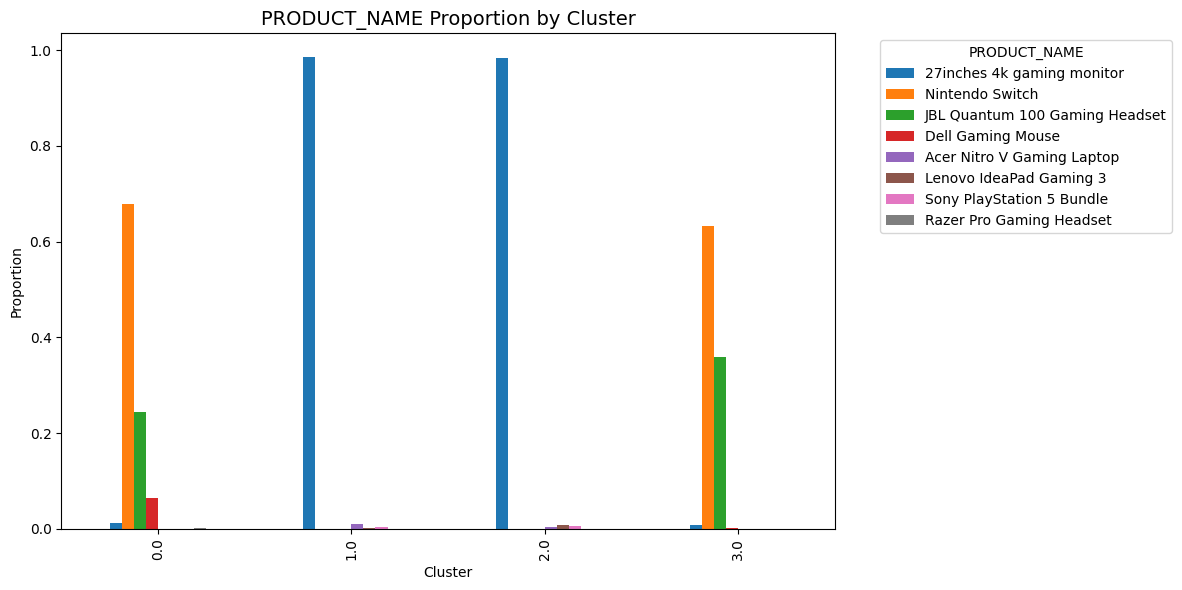

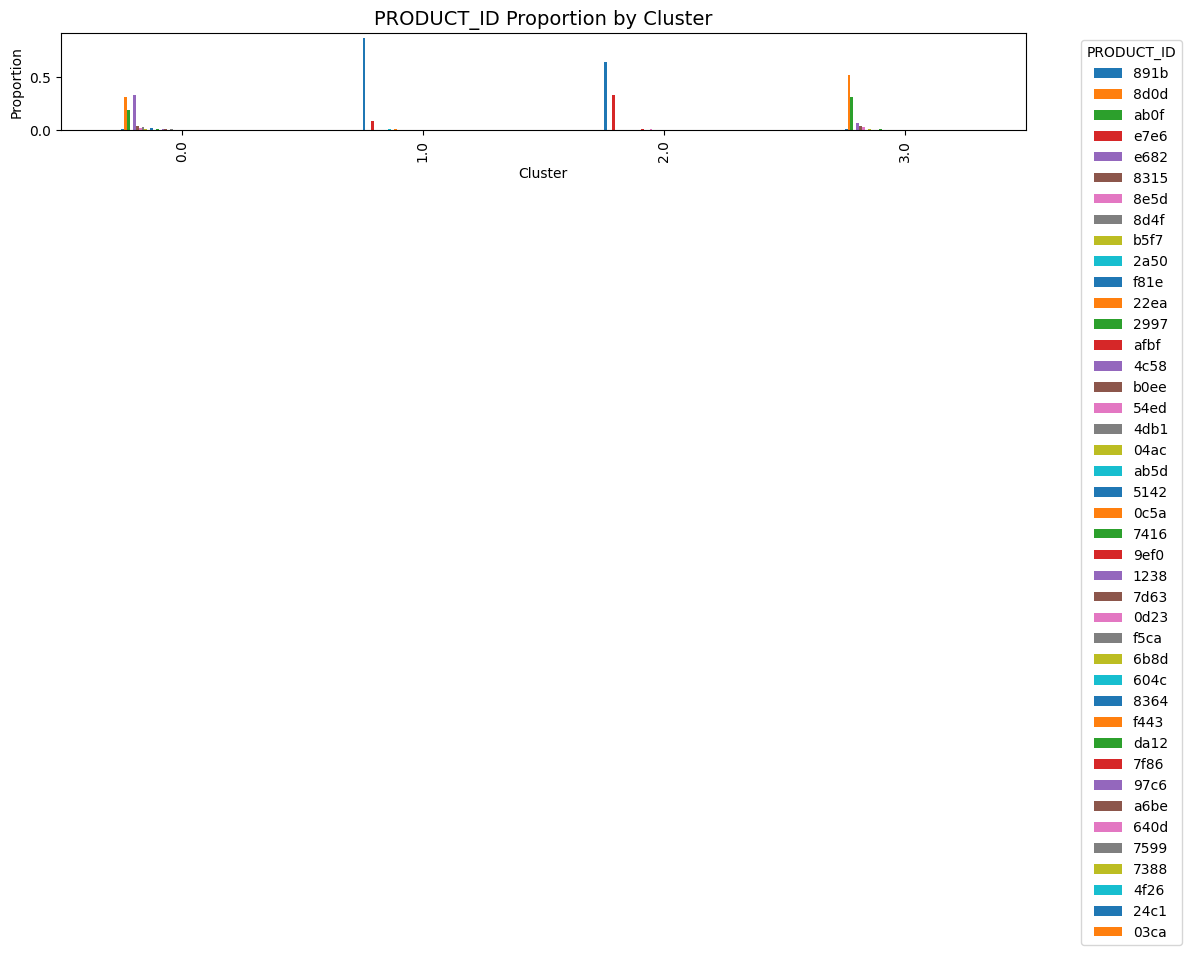

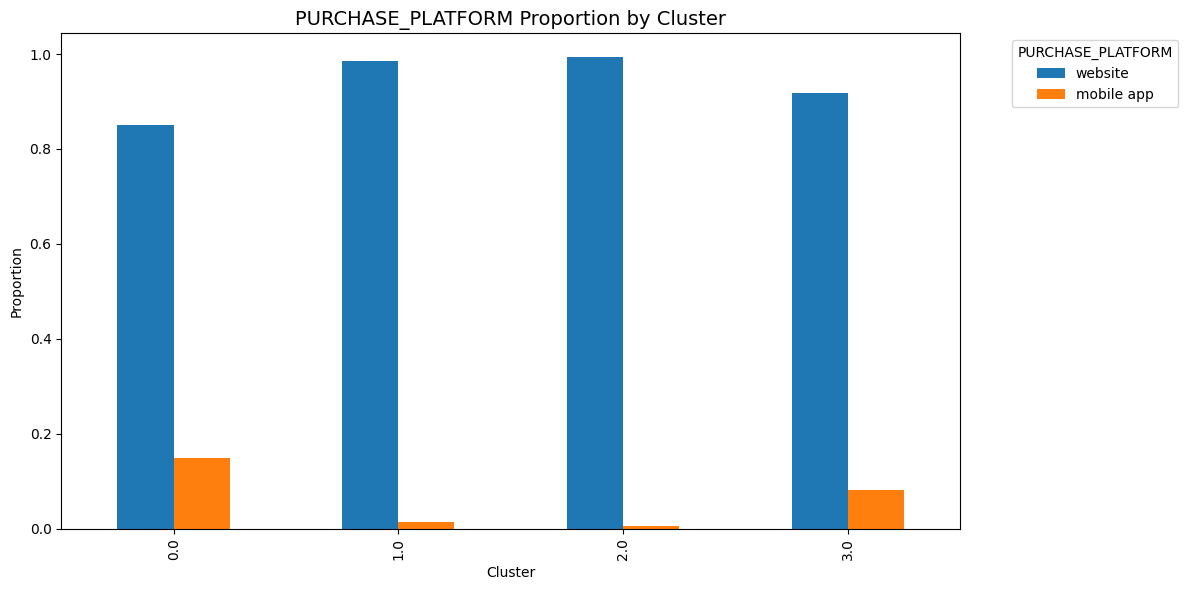

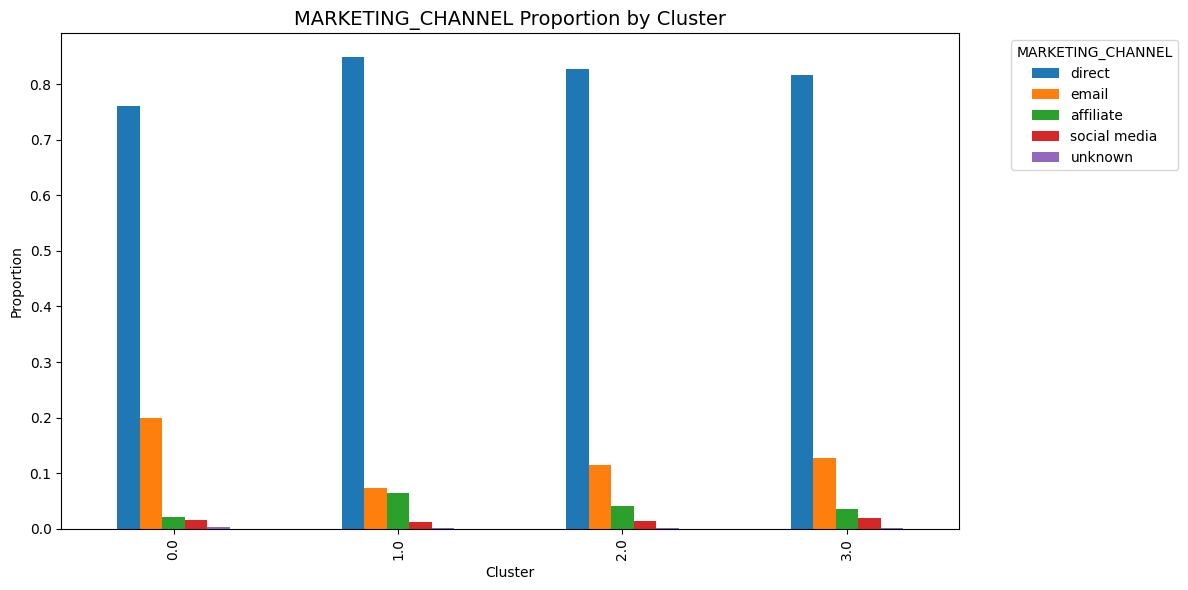

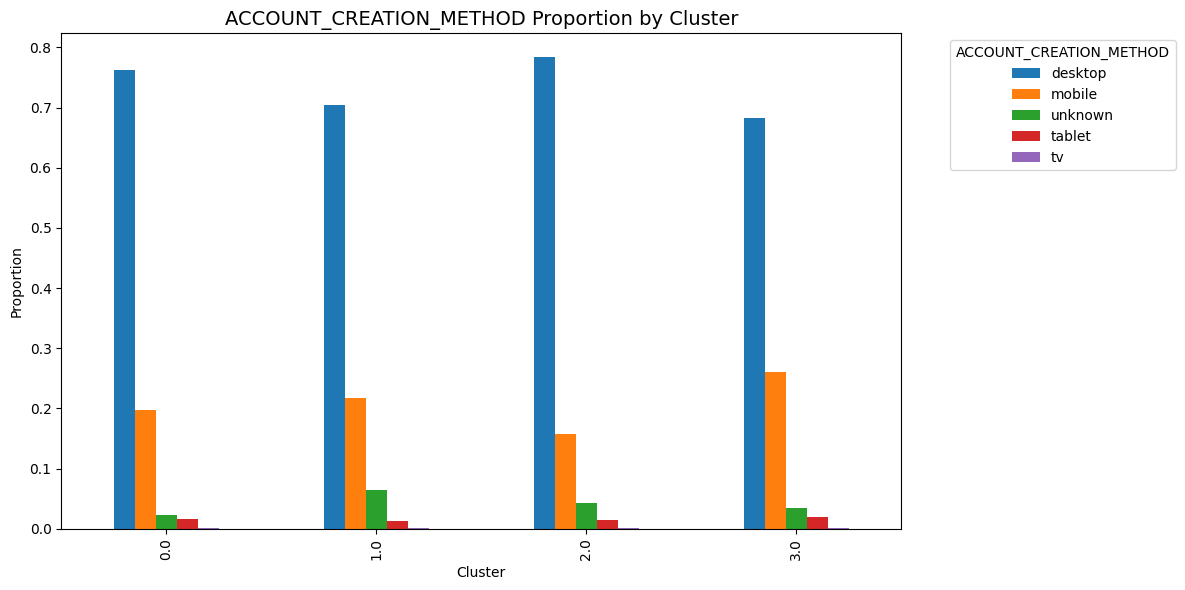

/var/folders/sd/dlvqbkgs15xb1zf5vbzsp_2w0000gn/T/ipykernel_85141/3646798298.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


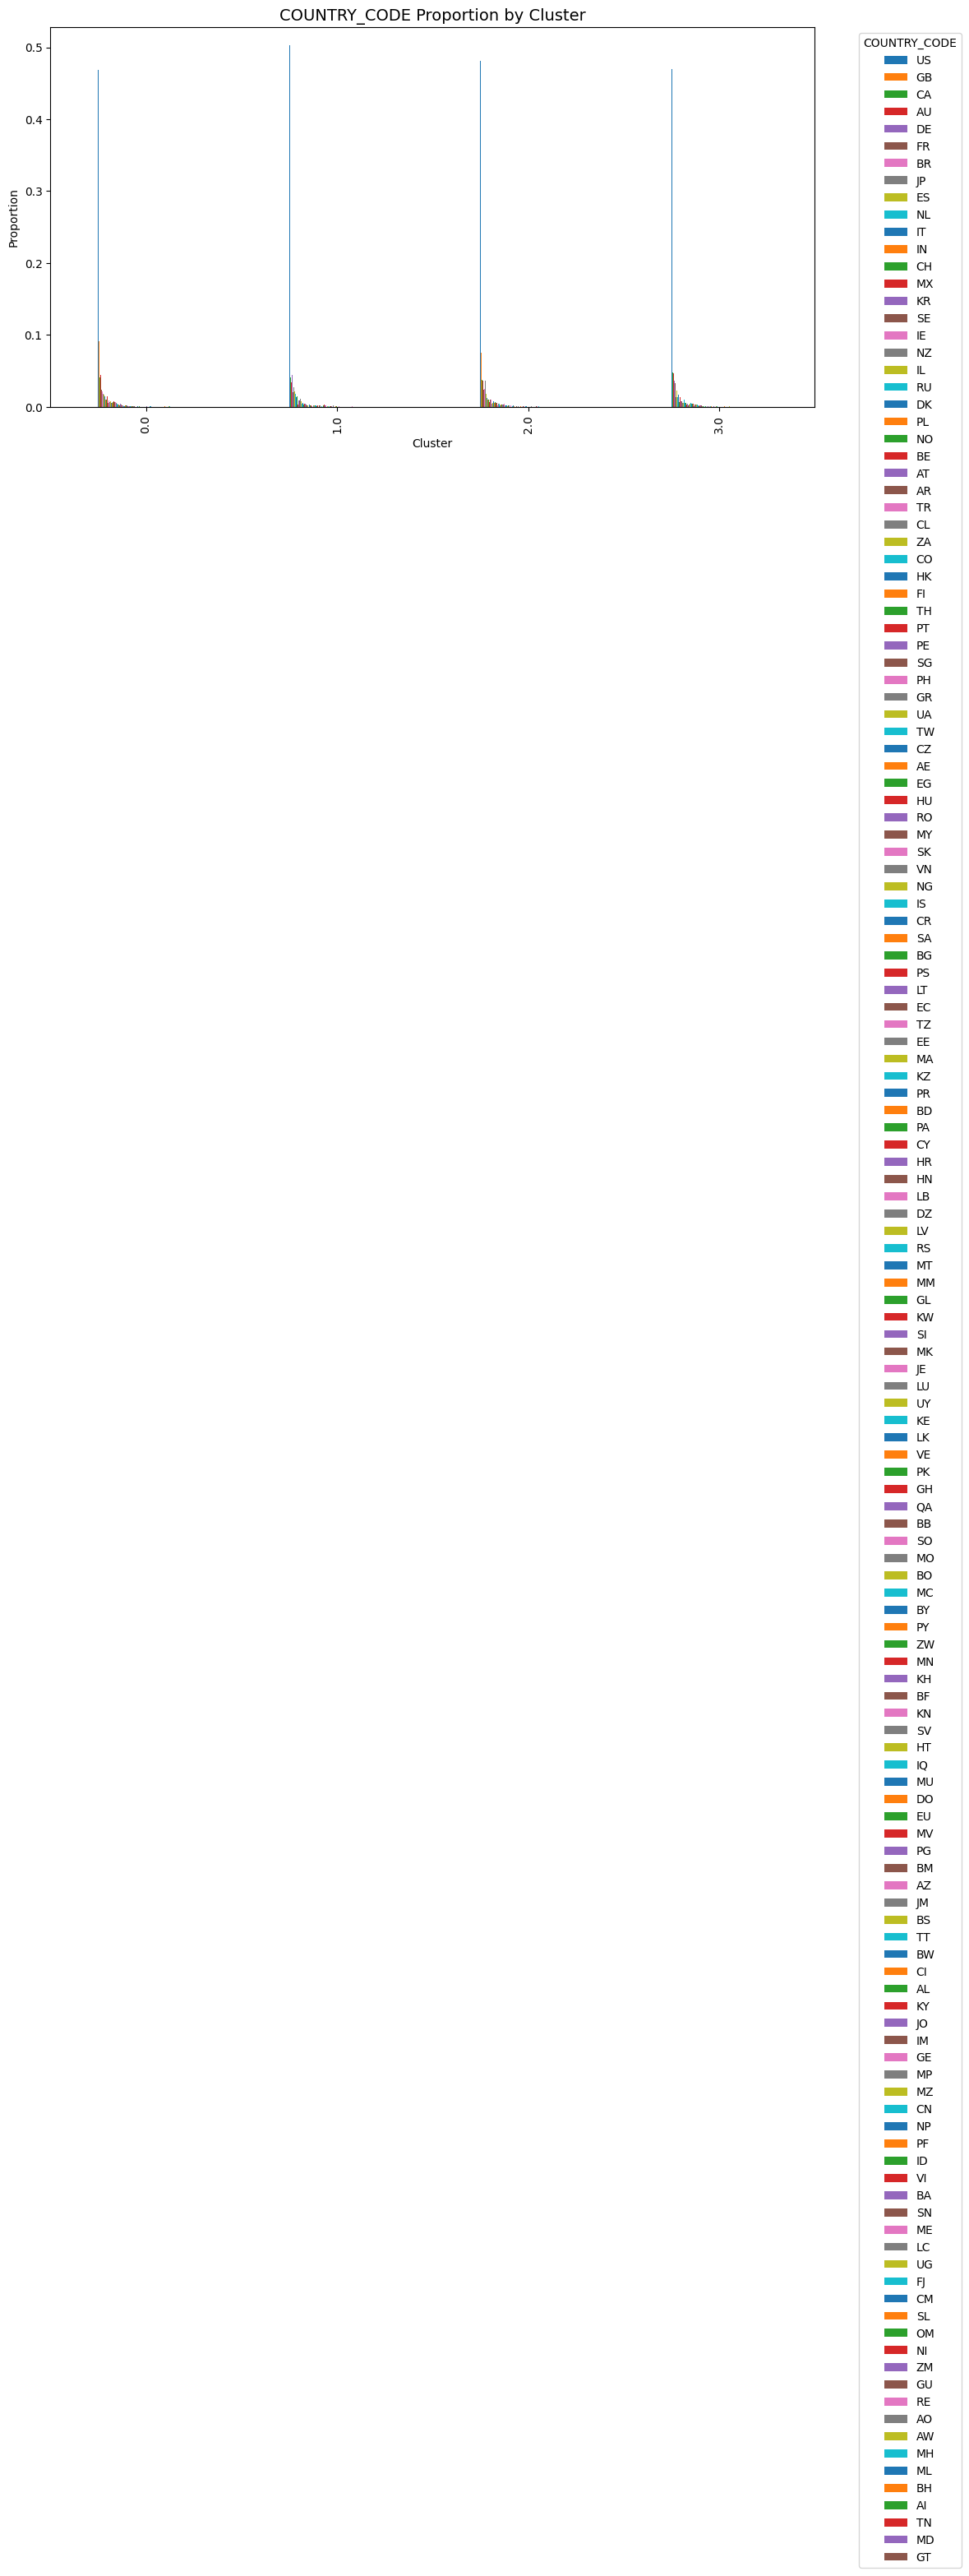

In [148]:
# after making preliminary assessments of clusters, we can further identify them with the below "leftover" dimensions not used/manipulated to create the clusters:

# dimensions: product_name, product_id,, purchase_platform, marketing_channel, account_creation_method, country_code


# Categorical features to visualize by cluster
categorical_features = [
    "PRODUCT_NAME",
    "PRODUCT_ID",
    "PURCHASE_PLATFORM",
    "MARKETING_CHANNEL",
    "ACCOUNT_CREATION_METHOD",
    "COUNTRY_CODE"
]

# Dictionary to store proportional tables
cluster_profile_tables = {}

# Loop through each feature
for feature in categorical_features:
    # Count table
    count_df = (
        joined_non_outliers_df
        .groupby(["Cluster", feature])
        .size()
        .unstack(fill_value=0)
    )

    # Convert counts to proportions within each cluster
    prop_df = count_df.div(count_df.sum(axis=1), axis=0)

    # Sort categories by overall descending proportion (across all clusters)
    sorted_cols = prop_df.mean(axis=0).sort_values(ascending=False).index
    prop_df = prop_df[sorted_cols]

    # Store table
    cluster_profile_tables[feature] = prop_df

    # Plot
    prop_df.plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(f"{feature} Proportion by Cluster", fontsize=14)
    plt.xlabel("Cluster")
    plt.ylabel("Proportion")
    plt.legend(title=feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    #significant tables are looking like PRODUCT_NAME and COUNTRY_CODE

In [149]:


product_props = joined_non_outliers_df['PRODUCT_NAME'].value_counts().reset_index()

sum_count = product_props['count'].sum()

sum_count

np.int64(16484)

In [150]:
product_props['props'] = product_props['count'] / sum_count

In [151]:
product_props

,PRODUCT_NAME,count,props
0,Nintendo Switch,8545,0.518381
1,27inches 4k gaming monitor,3692,0.223975
2,JBL Quantum 100 Gaming Headset,3624,0.219850
3,Dell Gaming Mouse,562,0.034094
4,Acer Nitro V Gaming Laptop,21,0.001274
5,Lenovo IdeaPad Gaming 3,19,0.001153
6,Sony PlayStation 5 Bundle,15,0.000910
7,Razer Pro Gaming Headset,6,0.000364


In [152]:
 #significant tables are looking like PRODUCT_NAME and COUNTRY_CODE
cluster_profile_tables['PRODUCT_NAME']

PRODUCT_NAME,27inches 4k gaming monitor,Nintendo Switch,JBL Quantum 100 Gaming Headset,Dell Gaming Mouse,Acer Nitro V Gaming Laptop,Lenovo IdeaPad Gaming 3,Sony PlayStation 5 Bundle,Razer Pro Gaming Headset
Cluster,,,,,,,,
0.0,0.012323,0.678912,0.243083,0.064985,0.000000,0.000000,0.000000,0.000698
1.0,0.986195,0.000000,0.000000,0.000000,0.009491,0.001726,0.002588,0.000000
2.0,0.984062,0.000000,0.000000,0.000000,0.004087,0.006947,0.004904,0.000000
3.0,0.008185,0.632601,0.358513,0.000702,0.000000,0.000000,0.000000,0.000000


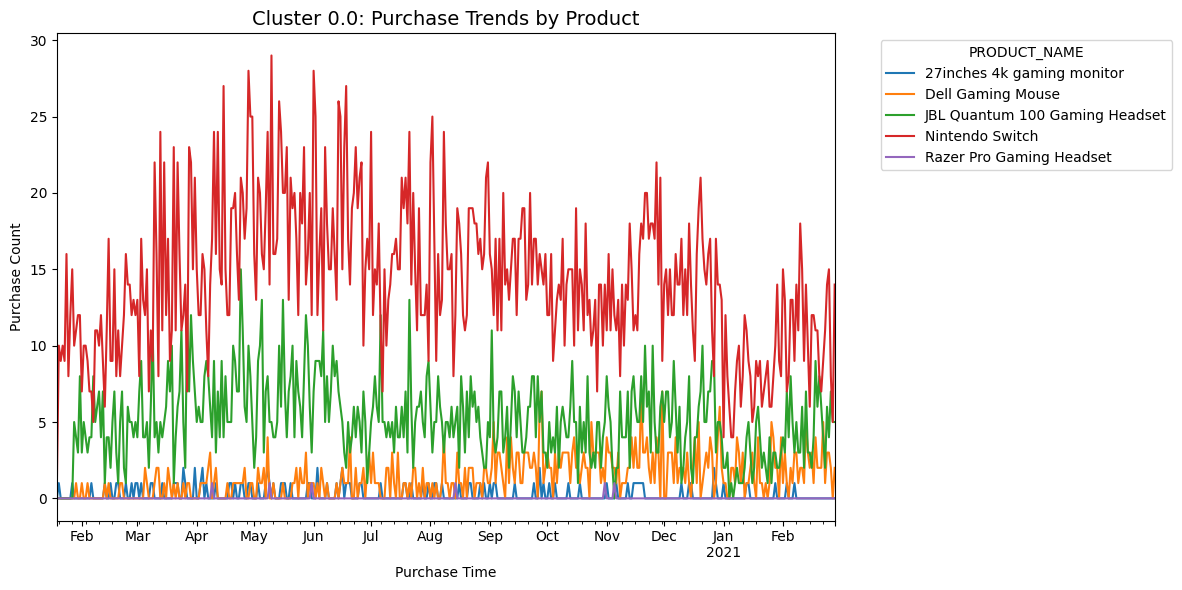

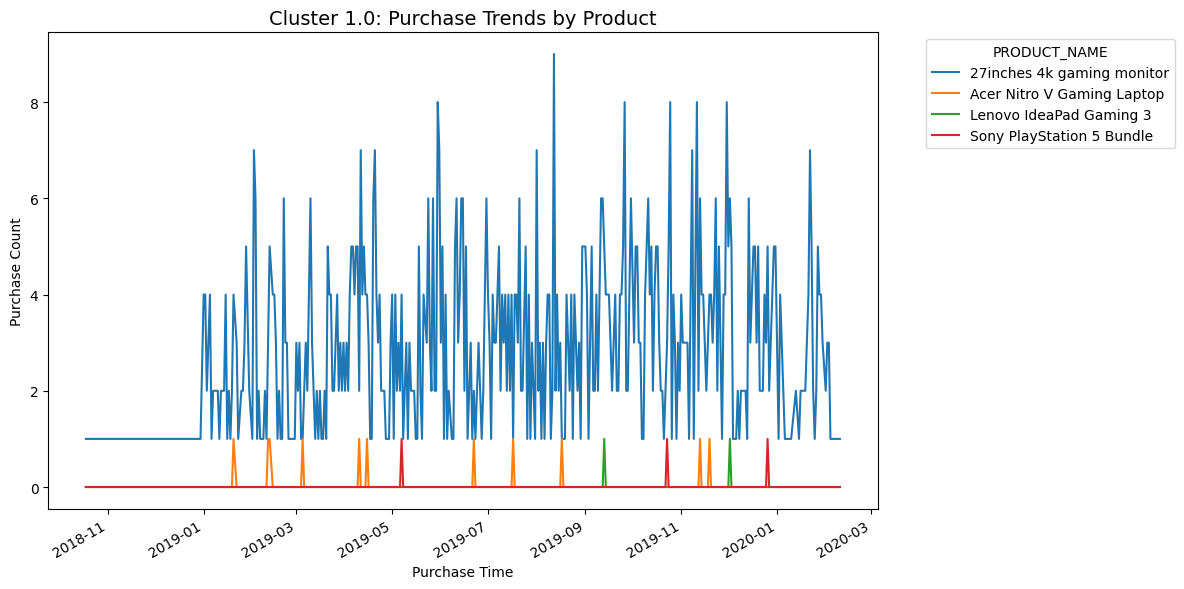

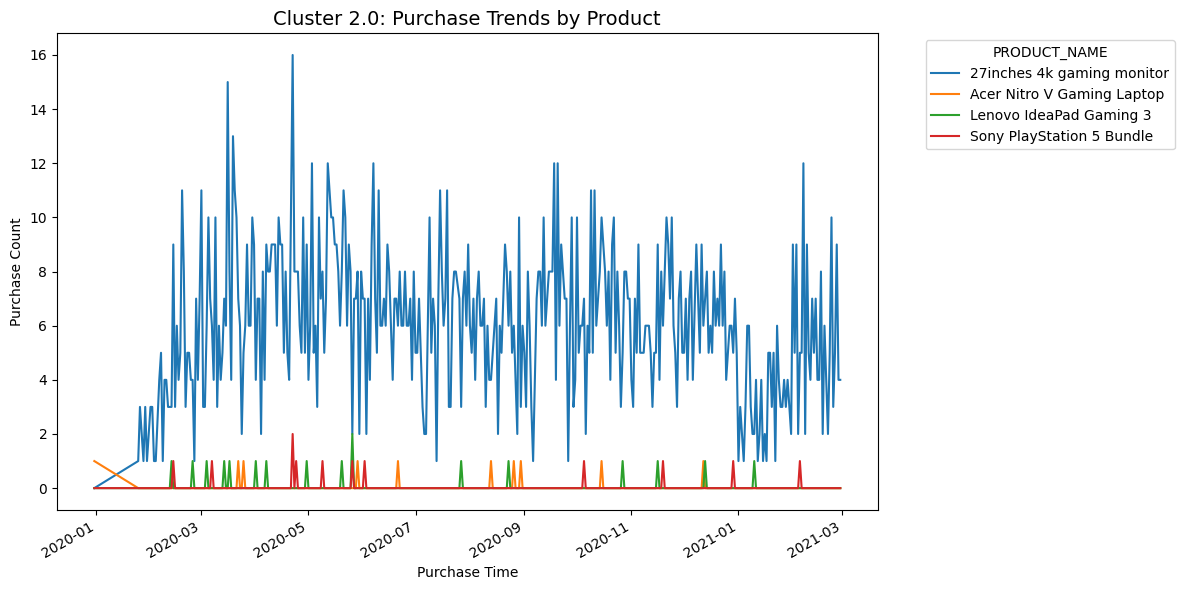

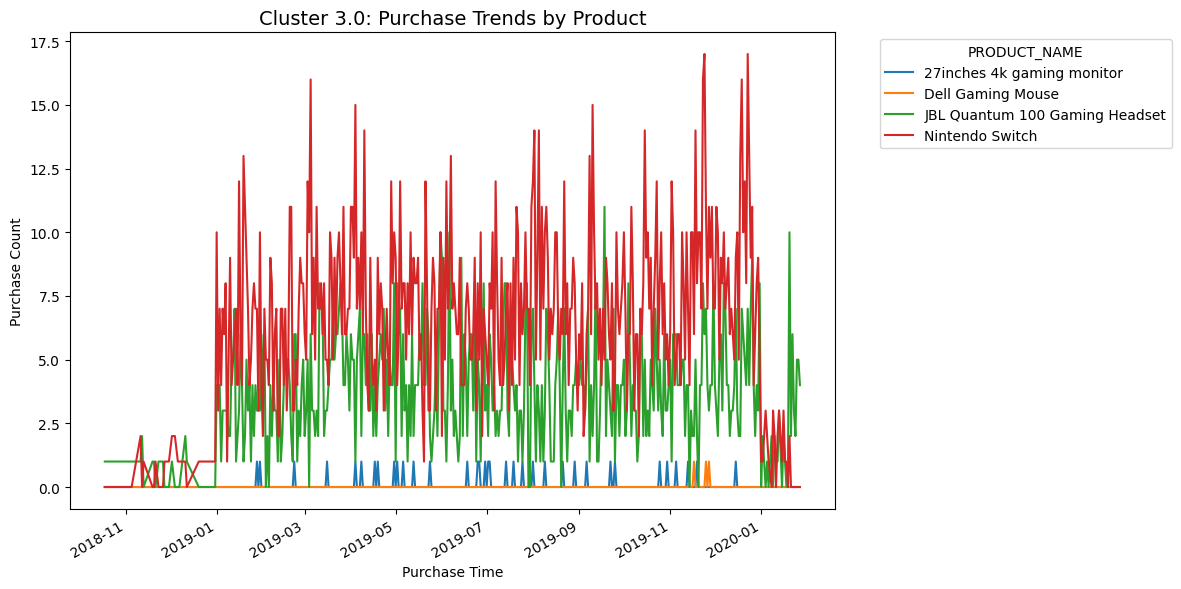

In [153]:

# Ensure timestamp is datetime
joined_non_outliers_df["PURCHASE_TS"] = (
    joined_non_outliers_df["PURCHASE_TS"]
    .dt.to_timestamp()
)

# Optional: choose aggregation level (D = daily, W = weekly, M = monthly)
TIME_FREQ = "D"

# Loop through clusters (assumes 4 clusters: 0–3)
for cluster in sorted(joined_non_outliers_df["Cluster"].unique()):
    
    cluster_df = joined_non_outliers_df[
        joined_non_outliers_df["Cluster"] == cluster
    ]

    # Aggregate purchase counts by time and product
    ts_df = (
        cluster_df
        .groupby([
            pd.Grouper(key="PURCHASE_TS", freq=TIME_FREQ),
            "PRODUCT_NAME"
        ])
        .size()
        .reset_index(name="purchase_count")
    )

    # Pivot for plotting
    pivot_df = ts_df.pivot(
        index="PURCHASE_TS",
        columns="PRODUCT_NAME",
        values="purchase_count"
    ).fillna(0)

    # Plot
    plt.figure(figsize=(12, 6))
    pivot_df.plot(ax=plt.gca())

    plt.title(f"Cluster {cluster}: Purchase Trends by Product", fontsize=14)
    plt.xlabel("Purchase Time")
    plt.ylabel("Purchase Count")
    plt.legend(title="PRODUCT_NAME", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [154]:
non_outliers_df.head(19)

,USER_ID,MonetaryValue,LastPurchaseDate,Frequency,Recency,Cluster
0,185974,275.37,2020-12-10,1,80,0
2,266910,168.00,2019-05-27,1,643,3
3,268826,392.30,2020-03-31,1,334,2
4,292751,168.00,2020-10-22,1,129,0
6,312959,168.00,2020-10-28,1,123,0
7,332998,167.35,2019-07-27,1,582,3
8,387435,21.60,2020-04-06,1,328,0
10,631691,177.11,2020-07-20,1,223,0
11,758931,168.00,2021-01-28,1,31,0
12,970353,84.49,2020-06-17,1,256,0
